# Exp 2: Text-Only Baseline — DistilBERT + MLP

**Goal:** Unimodal text-only baseline using pre-cached DistilBERT CLS embeddings (dim=768).

**Hyperparameters:** Auto-loaded from `results/tuning/exp2_best_params.json` if available, else falls back to defaults.

**Metric:** AUC-ROC (primary), Accuracy (secondary)

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json, os, copy
import warnings

warnings.filterwarnings('ignore')

ROOT = Path("../../").parent.resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Root path: {ROOT}')

Using device: mps
Root path: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


## 1. Load Embeddings

In [2]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'

X_train = np.load(TEXT_DIR / 'train_distilbert.npy').astype(np.float32)
y_train = np.load(IMG_DIR  / 'train_labels.npy')
X_dev   = np.load(TEXT_DIR / 'dev_distilbert.npy').astype(np.float32)
y_dev   = np.load(IMG_DIR  / 'dev_labels.npy')
X_test  = np.load(TEXT_DIR / 'test_distilbert.npy').astype(np.float32)
y_test  = np.load(IMG_DIR  / 'test_labels.npy')

print(f'Train: {X_train.shape} | Dev: {X_dev.shape} | Test: {X_test.shape}')
print(f'Label dist (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train: (8500, 768) | Dev: (500, 768) | Test: (1000, 768)
Label dist (train) — 0: 5450, 1: 3050


## 2. Normalize

In [3]:
scaler  = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_dev   = scaler.transform(X_dev)
X_test  = scaler.transform(X_test)
print('Normalized with StandardScaler (fit on train only).')

Normalized with StandardScaler (fit on train only).


## 3. Load Tuned Hyperparameters

In [4]:
tuning_path = ROOT / 'results/tuning/exp2_best_params.json'
if tuning_path.exists():
    p = json.load(open(tuning_path))['params']
    print(f'Loaded tuned params: {p}')
else:
    p = {'hidden1': 256, 'hidden2': 64, 'dropout1': 0.3, 'dropout2': 0.2,
         'lr': 3e-4, 'weight_decay': 1e-4}
    print(f'Tuning params not found — using defaults: {p}')

Loaded tuned params: {'hidden1': 128, 'hidden2': 64, 'dropout1': 0.49895798560352256, 'dropout2': 0.1952262723429521, 'lr': 0.004906509649994044, 'weight_decay': 0.0012464402007299144}


## 4. DataLoaders

In [5]:
BATCH_SIZE = 64

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
dev_loader   = make_loader(X_dev,   y_dev)
test_loader  = make_loader(X_test,  y_test)
print(f'Batches — Train: {len(train_loader)}, Dev: {len(dev_loader)}, Test: {len(test_loader)}')

Batches — Train: 133, Dev: 8, Test: 16


## 5. Model
```
DistilBERT CLS [768] → Linear(h1) → LayerNorm → GELU → Dropout(d1)
                     → Linear(h2) → LayerNorm → GELU → Dropout(d2)
                     → Linear(1)
```

In [6]:
class TextMLP(nn.Module):
    def __init__(self, input_dim=768, h1=256, h2=64, d1=0.3, d2=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),        nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

model = TextMLP(input_dim=768, h1=p['hidden1'], h2=p['hidden2'],
                d1=p['dropout1'], d2=p['dropout2']).to(DEVICE)

print(f'pos_weight: {pos_weight.item():.3f}')
print(f'Trainable params: {sum(par.numel() for par in model.parameters() if par.requires_grad):,}')
print(model)

pos_weight: 1.787
Trainable params: 107,137
TextMLP(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.49895798560352256, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1952262723429521, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 6. Training Setup

In [7]:
EPOCHS       = 50
LR           = p['lr']
WEIGHT_DECAY = p['weight_decay']
PATIENCE     = 10

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f'LR: {LR} | WD: {WEIGHT_DECAY} | Epochs: {EPOCHS} | Patience: {PATIENCE}')

LR: 0.004906509649994044 | WD: 0.0012464402007299144 | Epochs: 50 | Patience: 10


## 7. Train

In [8]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc)
    history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc
        best_state   = copy.deepcopy(model.state_dict())
        patience_ctr = 0
        flag = '  <- best'
    else:
        patience_ctr += 1
        flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} Acc {tr_acc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Dev AUC: {best_dev_auc:.4f}')
model.load_state_dict(best_state)

Ep 01 | Tr Loss 0.8206 AUC 0.6837 Acc 0.6467 | Dev Loss 0.9846 AUC 0.6221 Acc 0.5860  <- best
Ep 02 | Tr Loss 0.7808 AUC 0.7299 Acc 0.6805 | Dev Loss 1.0329 AUC 0.6205 Acc 0.5780  (patience 1/10)
Ep 03 | Tr Loss 0.7656 AUC 0.7449 Acc 0.6882 | Dev Loss 0.9619 AUC 0.6264 Acc 0.6020  <- best
Ep 04 | Tr Loss 0.7522 AUC 0.7560 Acc 0.6932 | Dev Loss 1.0301 AUC 0.6255 Acc 0.5860  (patience 1/10)
Ep 05 | Tr Loss 0.7375 AUC 0.7680 Acc 0.7022 | Dev Loss 1.0417 AUC 0.6297 Acc 0.5880  <- best
Ep 06 | Tr Loss 0.7302 AUC 0.7734 Acc 0.7033 | Dev Loss 1.1169 AUC 0.6302 Acc 0.5920  <- best
Ep 07 | Tr Loss 0.7155 AUC 0.7849 Acc 0.7116 | Dev Loss 1.0471 AUC 0.6354 Acc 0.5840  <- best
Ep 08 | Tr Loss 0.7121 AUC 0.7870 Acc 0.7140 | Dev Loss 1.0866 AUC 0.6294 Acc 0.5920  (patience 1/10)
Ep 09 | Tr Loss 0.6995 AUC 0.7970 Acc 0.7209 | Dev Loss 1.0194 AUC 0.6249 Acc 0.5820  (patience 2/10)
Ep 10 | Tr Loss 0.6936 AUC 0.7998 Acc 0.7149 | Dev Loss 1.1188 AUC 0.6294 Acc 0.5780  (patience 3/10)
Ep 11 | Tr Loss 0.67

<All keys matched successfully>

## 8. Training Curves

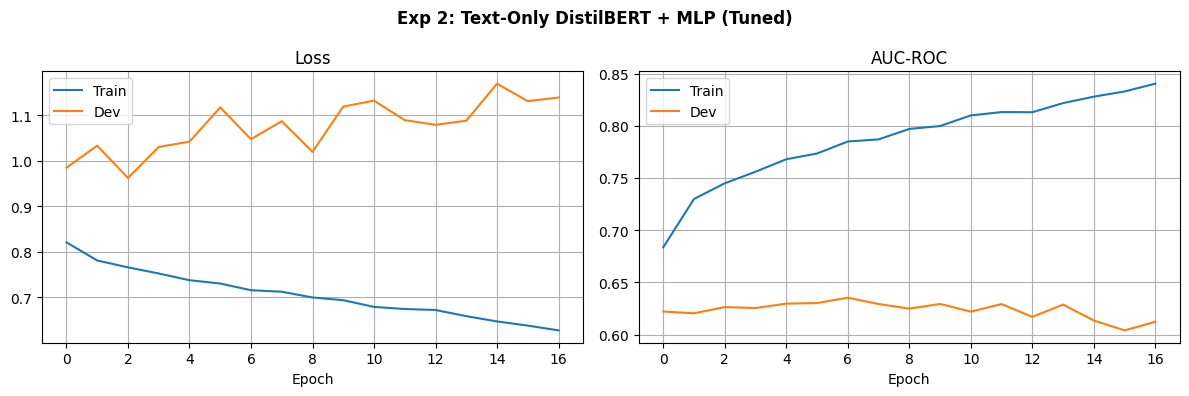

In [9]:
os.makedirs(ROOT / 'outputs', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['dev_loss'],   label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train')
axes[1].plot(history['dev_auc'],   label='Dev')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 2: Text-Only DistilBERT + MLP (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/02_training_curves.png', dpi=150)
plt.show()

## 9. Final Evaluation

In [10]:
_, dev_auc, dev_acc, dev_probs, dev_true = run_epoch(dev_loader, model, criterion)
dev_preds = (dev_probs >= 0.5).astype(int)
print('=' * 50)
print('EXP 2 — Text-Only (DistilBERT + MLP) | Dev Set')
print('=' * 50)
print(f'AUC-ROC  : {dev_auc:.4f}')
print(f'Accuracy : {dev_acc:.4f}')
print()
print(classification_report(dev_true, dev_preds, target_names=['Not Hateful', 'Hateful']))

# Compare with Exp 1
exp1_path = ROOT / 'results/exp1.json'
if exp1_path.exists():
    exp1 = json.load(open(exp1_path))
    print(f'\nExp 1 (Image-only): AUC = {exp1["dev_auc_roc"]:.4f}')
    print(f'Exp 2 (Text-only) : AUC = {dev_auc:.4f}')
    print(f'Text vs Image delta: {dev_auc - exp1["dev_auc_roc"]:+.4f}')

EXP 2 — Text-Only (DistilBERT + MLP) | Dev Set
AUC-ROC  : 0.6354
Accuracy : 0.5840

              precision    recall  f1-score   support

 Not Hateful       0.56      0.73      0.64       250
     Hateful       0.62      0.44      0.51       250

    accuracy                           0.58       500
   macro avg       0.59      0.58      0.57       500
weighted avg       0.59      0.58      0.57       500


Exp 1 (Image-only): AUC = 0.5667
Exp 2 (Text-only) : AUC = 0.6354
Text vs Image delta: +0.0687


## 10. Save Model & Results

In [11]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'results', exist_ok=True)

torch.save(best_state, ROOT / 'models/02_distilbert_mlp.pt')

results = {
    'experiment': '02_TextOnly_DistilBERT_MLP',
    'dev_auc_roc': round(float(dev_auc), 4),
    'dev_accuracy': round(float(dev_acc), 4),
    'model': f'DistilBERT CLS (768) + MLP({p["hidden1"]},{p["hidden2"]})',
    'modality': 'text-only',
    'params': p
}
with open(ROOT / 'results/exp2.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Model   → models/02_distilbert_mlp.pt')
print('Results → results/exp2.json')
print(json.dumps(results, indent=2))

Model   → models/02_distilbert_mlp.pt
Results → results/exp2.json
{
  "experiment": "02_TextOnly_DistilBERT_MLP",
  "dev_auc_roc": 0.6354,
  "dev_accuracy": 0.584,
  "model": "DistilBERT CLS (768) + MLP(128,64)",
  "modality": "text-only",
  "params": {
    "hidden1": 128,
    "hidden2": 64,
    "dropout1": 0.49895798560352256,
    "dropout2": 0.1952262723429521,
    "lr": 0.004906509649994044,
    "weight_decay": 0.0012464402007299144
  }
}
